Rows after filtering: 47066
Year range: 1979 - 2021
Months present: [7, 8, 9, 10]
Sites present: ['DEEP RIVER', 'ENFIELD', 'ESSEX', 'GLASTONBURY', 'HOLYOKE', 'SALMON RIVER', 'WILSON']
DOY range: 182 - 302

Length summary:
Min: 31.0
Median: 66.0
Max: 165.0

Bins: ['30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100', '100-110', '110-120', '120-170']
Sites present: ['DEEP RIVER', 'ENFIELD', 'ESSEX', 'GLASTONBURY', 'HOLYOKE', 'SALMON RIVER', 'WILSON']
Years present: [1979, 1980, 1981, 1982, 1984, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021]


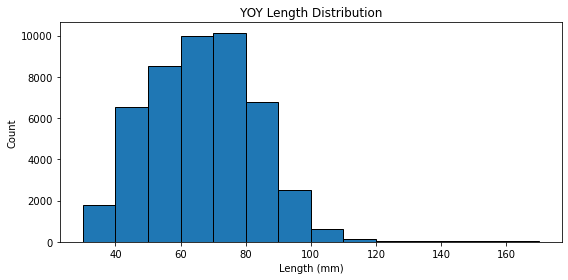


Histogram year: 2018
Sites present in this subset: ['DEEP RIVER', 'ENFIELD', 'ESSEX', 'GLASTONBURY', 'HOLYOKE', 'SALMON RIVER', 'WILSON']
Years present in this subset: [2018]


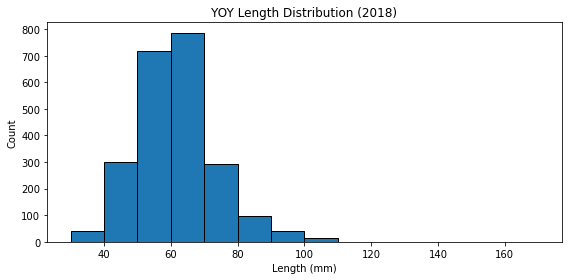


Counts by Month x SizeBin (overall):
SizeBin  30-40  40-50  50-60  60-70  70-80  80-90  90-100  100-110  110-120  \
Month                                                                         
7         1358   4084   3482   1616    587    122      18        0        0   
8          395   2289   4180   4926   3156   1116     284       44        9   
9           22    138    810   2939   4960   3494    1120      294       61   
10           1     18     72    494   1435   2072    1083      287       57   

SizeBin  120-170  
Month             
7              7  
8              2  
9             18  
10            16  


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ============================================================
# SETTINGS
# ============================================================
DATA_FILE = "Juvenile_Master_Length_Data_1978_2021.csv"   # data file
SHEETS = None                                             
SPECIES = "ASD"

YEAR_MIN, YEAR_MAX = 1979, 2021
MONTHS = [7, 8, 9, 10]                                    # available months
TRANS_FROM, TRANS_TO = 7, 9                               # transition period: July -> September

# These are kept only for reference; the actual bins are defined manually below.
BIN_WIDTH = 10                                            # kept for reference 
BIN_START = 30                                            # kept for reference 
BIN_END = 170                                             # kept for reference 

                                              

# ------------------------------------------------------------
# TRANSITION CONSTRAINTS
# ------------------------------------------------------------
# Direct July -> September transition
KMAX_DIRECT = 3   # max allowed bin jump
# Monthly transitions used in composition:
# July -> August and August -> September
KMAX_MONTHLY = 2   # max allowed bin jump


# ------------------------------------------------------------
# SITE OPTIONS
# ------------------------------------------------------------
# Use SITE_FILTER to choose specific sites directly, e.g.
# SITE_FILTER = ["HOLYOKE", "ENFIELD"]
# or leave as None to use all sites.
SITE_FILTER = None

# Site groups for spatial analysis
SITE_GROUPS = {
    "UPPER": ["WILSON", "ENFIELD", "HOLYOKE"],
    "LOWER": ["GLASTONBURY", "SALMON RIVER", "DEEP RIVER", "ESSEX"]
}

# Choose one group or leave None
# Example: SITE_GROUP = "UPPER"
SITE_GROUP = None

np.random.seed(0)

# ============================================================
# READ DATA (CSV or XLSX)
# ============================================================
def read_length_data(path, sheets=None):
    ext = os.path.splitext(path)[1].lower()

    if ext in [".csv", ".txt"]:
        return pd.read_csv(path)

    elif ext in [".xlsx", ".xls"]:
        xls = pd.ExcelFile(path)
        if sheets is None:
            sheets = xls.sheet_names

        frames = []
        for sh in sheets:
            tmp = pd.read_excel(path, sheet_name=sh)
            tmp["SheetName"] = sh
            frames.append(tmp)

        return pd.concat(frames, ignore_index=True)

    else:
        raise ValueError(f"Unsupported file extension: {ext}")


# ============================================================
# STANDARDIZE COLUMN NAMES
# ============================================================
def standardize_columns(df):
    rename_map = {}

    for c in df.columns:
        cl = str(c).strip().lower()

        if cl == "species":
            rename_map[c] = "Species"
        elif cl == "length":
            rename_map[c] = "Length"
        elif cl == "year":
            rename_map[c] = "Year"
        elif cl == "month":
            rename_map[c] = "Month"
        elif cl == "date":
            rename_map[c] = "Date"
        elif cl == "doy":
            rename_map[c] = "DOY"
        elif cl == "site":
            rename_map[c] = "Site"
        elif cl == "sitenum":
            rename_map[c] = "SiteNum"
        elif cl == "temp":
            rename_map[c] = "Temp"
        elif cl == "source":
            rename_map[c] = "Source"

    df = df.rename(columns=rename_map)
    return df


# ============================================================
# APPLY OPTIONAL SITE FILTERING
# ============================================================
def apply_site_filter(df, site_filter=None, site_group=None, site_groups=None):
    df = df.copy()

    if "Site" not in df.columns:
        return df

    df["Site"] = df["Site"].astype(str).str.strip().str.upper()

    if site_group is not None:
        if site_groups is None or site_group not in site_groups:
            raise ValueError(f"Unknown SITE_GROUP: {site_group}")
        allowed_sites = [s.upper() for s in site_groups[site_group]]
        df = df[df["Site"].isin(allowed_sites)]

    elif site_filter is not None:
        allowed_sites = [s.upper() for s in site_filter]
        df = df[df["Site"].isin(allowed_sites)]

    return df


# ============================================================
# READ AND CLEAN DATA
# ============================================================
df_len = read_length_data(DATA_FILE, sheets=SHEETS)
df_len = standardize_columns(df_len)

# Convert columns to numeric where appropriate
df_len["Year"] = pd.to_numeric(df_len["Year"], errors="coerce")
df_len["Month"] = pd.to_numeric(df_len["Month"], errors="coerce")
df_len["Length"] = pd.to_numeric(df_len["Length"], errors="coerce")

if "DOY" in df_len.columns:
    df_len["DOY"] = pd.to_numeric(df_len["DOY"], errors="coerce")

if "Temp" in df_len.columns:
    df_len["Temp"] = pd.to_numeric(df_len["Temp"], errors="coerce")

df_len["Species"] = df_len["Species"].astype(str).str.strip().str.upper()

if "Date" in df_len.columns:
    df_len["Date"] = pd.to_datetime(df_len["Date"], errors="coerce")

# Optional site filtering
df_len = apply_site_filter(
    df_len,
    site_filter=SITE_FILTER,
    site_group=SITE_GROUP,
    site_groups=SITE_GROUPS
)

# Main filtering
df_len = df_len[
    (df_len["Species"] == SPECIES) &
    (df_len["Year"].between(YEAR_MIN, YEAR_MAX)) &
    (df_len["Month"].isin(MONTHS)) &
    (df_len["Length"].notna())
].copy()

if len(df_len) == 0:
    raise RuntimeError("No data remain after filtering. Check species, years, months, and site settings.")

print("Rows after filtering:", len(df_len))
print("Year range:", int(df_len["Year"].min()), "-", int(df_len["Year"].max()))
print("Months present:", sorted(df_len["Month"].dropna().unique().astype(int)))

if "Site" in df_len.columns:
    print("Sites present:", sorted(df_len["Site"].dropna().unique()))

if "DOY" in df_len.columns:
    print("DOY range:", int(df_len["DOY"].min()), "-", int(df_len["DOY"].max()))

# ============================================================
# SUMMARY STATS
# ============================================================
Lmin = float(df_len["Length"].min())
Lmed = float(df_len["Length"].median())
Lmax = float(df_len["Length"].max())

print("\nLength summary:")
print("Min:", Lmin)
print("Median:", Lmed)
print("Max:", Lmax)

# ============================================================
# DEFINE SIZE BINS
# ============================================================
# Use 10-mm size classes from 30 to 120 mm and combine larger fish into a terminal 120-170 mm class.
bins = np.array([
    30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 170
])

labels = [
    "30-40",
    "40-50",
    "50-60",
    "60-70",
    "70-80",
    "80-90",
    "90-100",
    "100-110",
    "110-120",
    "120-170"
]

df_len["SizeBin"] = pd.cut(df_len["Length"], bins=bins, right=False, labels=labels)

n_outside = df_len["SizeBin"].isna().sum()
if n_outside > 0:
    print(f"\nWarning: {n_outside} fish fall outside the bin range and will be dropped.")

df_len = df_len.dropna(subset=["SizeBin"]).copy()

print("\nBins:", labels)
if "Site" in df_len.columns:
    print("Sites present:", sorted(df_len["Site"].dropna().unique()))
#print("Sites present:", sorted(df_len["Site"].dropna().unique()))
print("Years present:", sorted(df_len["Year"].dropna().unique().astype(int)))

# ============================================================
# DIAGNOSTIC HISTOGRAM
# ============================================================
plt.figure(figsize=(8, 4))
plt.hist(df_len["Length"], bins=bins, edgecolor="black")
# if want different bins width
# plt.hist(df_len["Length"], bins=30, edgecolor="black")
plt.xlabel("Length (mm)")
plt.ylabel("Count")
plt.title("YOY Length Distribution")
plt.tight_layout()
plt.show()

# ============================================================
# HISTOGRAM FOR A GIVEN YEAR
# ============================================================
year = 2018
df_year = df_len[df_len["Year"] == year].copy()

print(f"\nHistogram year: {year}")
print("Sites present in this subset:", sorted(df_year["Site"].dropna().unique()))
print("Years present in this subset:", sorted(df_year["Year"].dropna().unique().astype(int)))

plt.figure(figsize=(8, 4))
plt.hist(df_year["Length"], bins=bins, edgecolor="black")
plt.xlabel("Length (mm)")
plt.ylabel("Count")
plt.title(f"YOY Length Distribution ({year})")
plt.tight_layout()
plt.show()

# ============================================================
# VERIFY COUNTS PER MONTH x BIN (overall)
# ============================================================
counts_month_bin = (
    df_len.groupby(["Month", "SizeBin"], observed=False)
          .size()
          .unstack(fill_value=0)
          .sort_index()
)

print("\nCounts by Month x SizeBin (overall):")
print(counts_month_bin)

# ============================================================
# BUILD MONTHLY LENGTH FREQUENCIES PER YEAR
# freqs[(year, month)] = vector of counts in size bins

# For each year and month, we convert individual fish lengths
# into a vector of counts across size classes.
# These vectors are the observed length-frequency distributions
# used in the Wood–Caswell inverse problem.
# ============================================================
def year_month_freq_table(df, year, month, labels):
    sub = df[(df["Year"] == year) & (df["Month"] == month)]
    v = sub["SizeBin"].value_counts().reindex(labels, fill_value=0).values.astype(float)
    return v

years = sorted(df_len["Year"].dropna().unique().astype(int))
freqs = {(y, m): year_month_freq_table(df_len, y, m, labels) for y in years for m in MONTHS}

# ============================================================
# NORMALIZE TO RELATIVE FREQUENCY
# ============================================================
def normalize_freq(v):
    v = np.asarray(v, dtype=float)
    s = v.sum()
    if s <= 0:
        return None
    return v / s

# ============================================================
# GET TWO MONTHLY VECTORS FOR ONE YEAR
# normalize=True  -> relative frequencies
# normalize=False -> raw counts
# ============================================================
def get_year_vectors(y, m_from, m_to, normalize=True):

    # Return the two size-bin vectors for one year and two selected months.
    # y : int
    #    Year of interest
    # m_from : int
    #    Starting month (for example, July = 7)
    # m_to : int
    #    Later month (for example, September = 9)
    # normalize : bool
    #    If True, return relative frequencies.
    #    If False, return raw counts.
    # Returns
    # f_from, f_to : numpy arrays or (None, None)
    #    Two vectors for the selected year and months.

    f_from = freqs.get((y, m_from))
    f_to   = freqs.get((y, m_to))

    if f_from is None or f_to is None:
        return None, None

    if f_from.sum() == 0 or f_to.sum() == 0:
        return None, None

    f_from = np.asarray(f_from, dtype=float)
    f_to   = np.asarray(f_to, dtype=float)

    if normalize:
        f_from = normalize_freq(f_from)
        f_to   = normalize_freq(f_to)

    return f_from, f_to

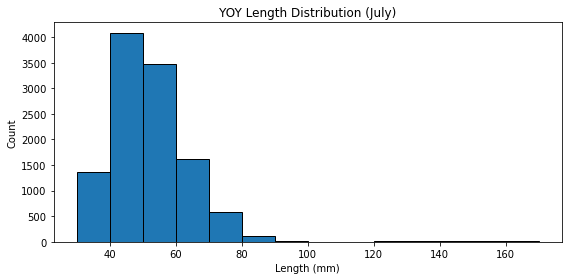

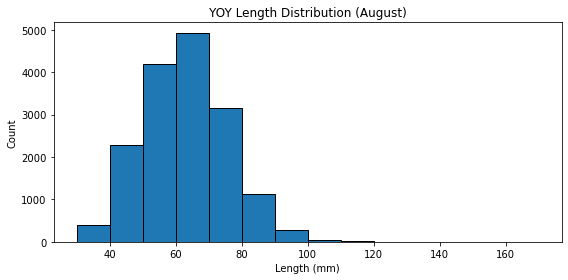

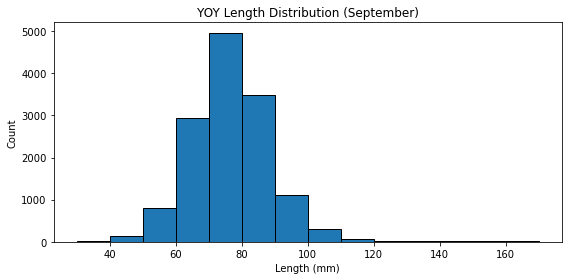

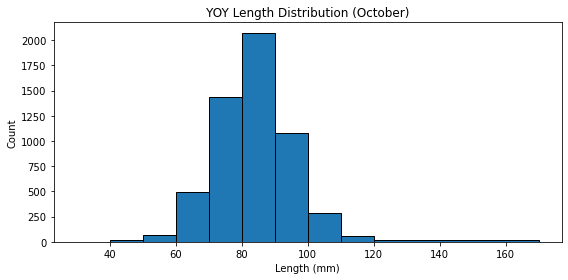

Month
7     11274
8     16401
9     13856
10     5535
dtype: int64


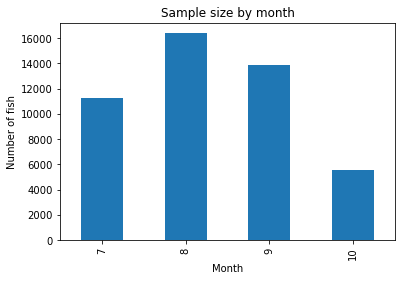

In [10]:
# ============================================================
# ALL SITES: MONTHLY LENGTH DISTRIBUTIONS 
# ============================================================
# These histograms help visualize how the length distribution shifts from July toward later months.

month_names = {7: "July", 8: "August", 9: "September", 10: "October"}

for m in MONTHS:
    sub = df_len[df_len["Month"] == m]
    
    plt.figure(figsize=(8, 4))
    plt.hist(sub["Length"], bins=bins, edgecolor="black")
    plt.xlabel("Length (mm)")
    plt.ylabel("Count")
    plt.title(f"YOY Length Distribution ({month_names.get(m, m)})")
    plt.tight_layout()
    plt.show()

# SAMPLE SIZE BY MONTH
counts_by_month = df_len.groupby("Month").size()
print(counts_by_month)
counts_by_month.plot(kind="bar")
plt.ylabel("Number of fish")
plt.title("Sample size by month")
plt.show()

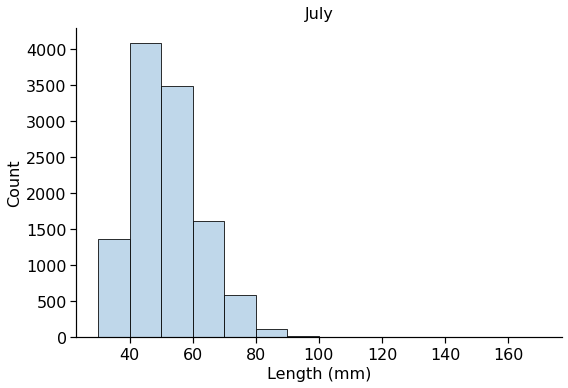

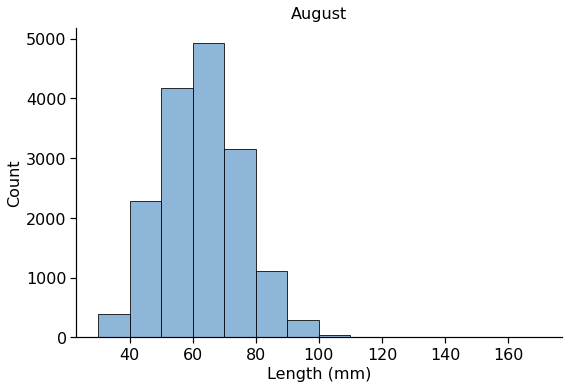

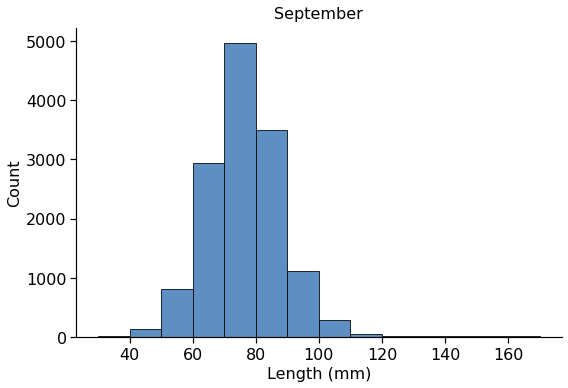

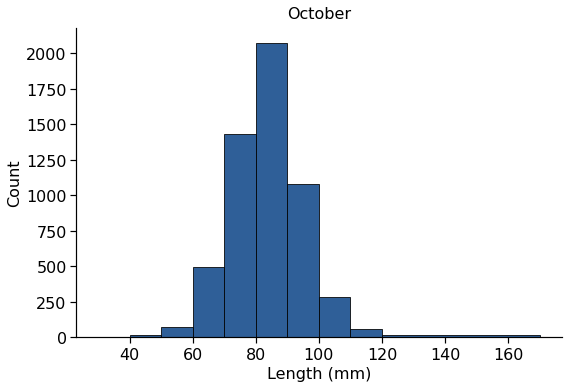

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# SETTINGS
# ============================================================

label_size = 16
tick_size = 16

month_names = {
    7: "July",
    8: "August",
    9: "September",
    10: "October"
}

month_colors = {
    7: "#BFD7EA",
    8: "#8DB6D9",
    9: "#5E8FC2",
    10: "#2F5F98"
}

# ============================================================
# MONTHLY LENGTH HISTOGRAMS
# ============================================================

for m in MONTHS:

    sub = df_len[df_len["Month"] == m]

    fig, ax = plt.subplots(figsize=(8, 5.5))

    ax.hist(
        sub["Length"].dropna(),
        bins=bins,
        color=month_colors[m],
        edgecolor="black",
        linewidth=0.8
    )

    ax.set_xlabel("Length (mm)", fontsize=label_size)
    ax.set_ylabel("Count", fontsize=label_size)
    
    # Month title
    ax.set_title(
    month_names[m],
    fontsize=16,
    pad=10
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=tick_size,
        width=1.2,
        length=6
    )

    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    ax.grid(False)
    sns.despine(ax=ax)

    fig.tight_layout()

    month_label = month_names.get(m, str(m)).lower()

    
    fig.savefig(
    f"histogram_{month_names[m]}.pdf",
    bbox_inches="tight"
    )

    plt.show()

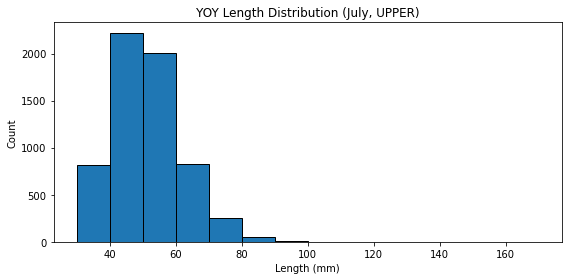

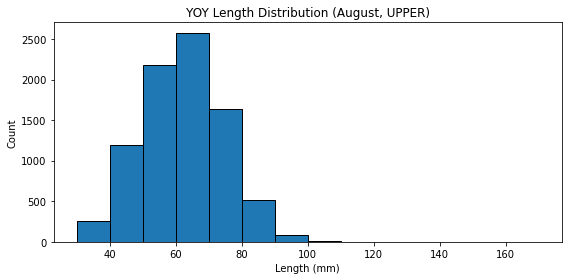

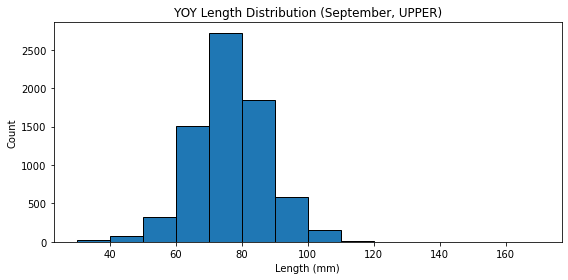

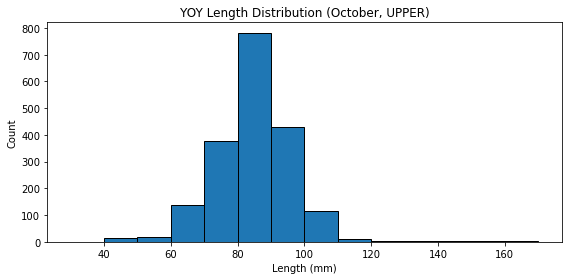

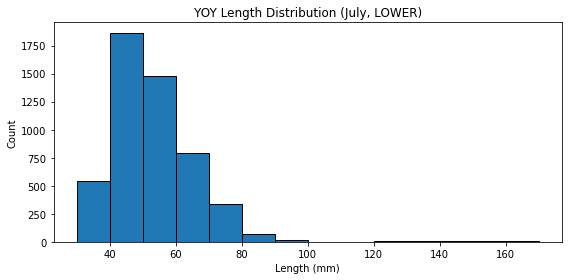

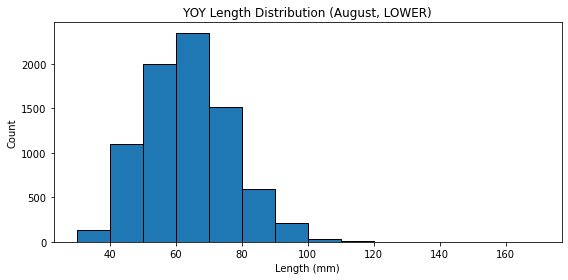

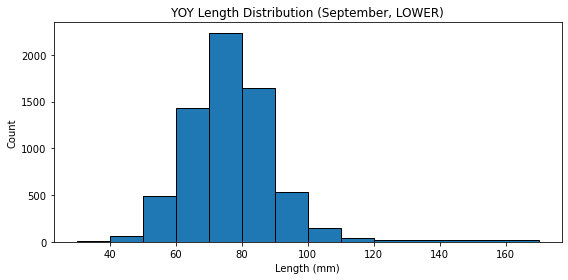

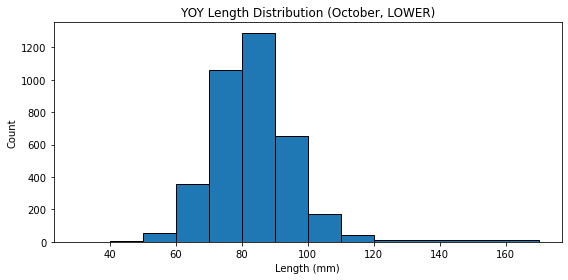


Counts by Month and River Part:
            July  August  September  October
UPPER       6177    8447       7251     1890
LOWER       5097    7954       6605     3645
All sites  11274   16401      13856     5535

Counts by Month x SizeBin (UPPER):
SizeBin  30-40  40-50  50-60  60-70  70-80  80-90  90-100  100-110  110-120  \
Month                                                                         
7          819   2220   2001    827    251     53       6        0        0   
8          258   1188   2178   2575   1640    521      78        9        0   
9           18     74    323   1508   2723   1851     589      148       16   
10           1     14     19    138    376    782     429      117       12   

SizeBin  120-170  
Month             
7              0  
8              0  
9              1  
10             2  

Counts by Month x SizeBin (LOWER):
SizeBin  30-40  40-50  50-60  60-70  70-80  80-90  90-100  100-110  110-120  \
Month                                          

In [12]:
# ============================================================
# DIAGNOSTIC: MONTHLY LENGTH DISTRIBUTIONS BY RIVER PART
# ============================================================

month_order = [7, 8, 9, 10]

month_names = {
    7: "July",
    8: "August",
    9: "September",
    10: "October"
}

def get_group_data(df, group_sites):
    allowed_sites = [s.upper() for s in group_sites]
    return df[df["Site"].isin(allowed_sites)].copy()


for group_name, group_sites in SITE_GROUPS.items():

    df_group = get_group_data(df_len, group_sites)

    for m in month_order:

        sub = df_group[df_group["Month"] == m]

        plt.figure(figsize=(8, 4))

        plt.hist(
            sub["Length"],
            bins=bins,
            edgecolor="black"
        )

        plt.xlabel("Length (mm)")
        plt.ylabel("Count")

        plt.title(
            f"YOY Length Distribution ({month_names[m]}, {group_name})"
        )

        plt.tight_layout()
        plt.show()


# ============================================================
# TABLE: SAMPLE SIZE BY MONTH AND RIVER PART
# ============================================================

rows = {}

for group_name, group_sites in SITE_GROUPS.items():

    df_group = get_group_data(df_len, group_sites)

    counts = (
        df_group.groupby("Month")
                .size()
                .reindex(month_order, fill_value=0)
    )

    rows[group_name] = counts.values

counts_all = (
    df_len.groupby("Month")
          .size()
          .reindex(month_order, fill_value=0)
)

rows["All sites"] = counts_all.values

table_counts = pd.DataFrame(
    rows,
    index=[month_names[m] for m in month_order]
).T

print("\nCounts by Month and River Part:")
print(table_counts)


# ============================================================
# COUNTS BY MONTH x SIZEBIN FOR EACH RIVER PART
# ============================================================

for group_name, group_sites in SITE_GROUPS.items():

    df_group = get_group_data(df_len, group_sites)

    counts_month_bin = (
        df_group.groupby(["Month", "SizeBin"], observed=False)
                .size()
                .unstack(fill_value=0)
                .reindex(month_order, fill_value=0)
    )

    print(f"\nCounts by Month x SizeBin ({group_name}):")
    print(counts_month_bin)


Demo direct transition: Year 2018, Month 7 -> 9
Sample size (from): 318
Sample size (to): 648

Optimization success: True | message: Optimization terminated successfully
Max abs residual: 0.0015432098765432098
L2 residual: 0.001951068870268602
Column sums (retention by starting bin; <= 1 allows apparent loss): [0.997 0.994 1.    0.997 1.    1.    1.    0.95  0.35  0.05 ]

Direct transition matrix P for 2018 (rows=to-bin, cols=from-bin):
         30-40  40-50  50-60  60-70  70-80  80-90  90-100  100-110  110-120  \
30-40    0.000  0.000  0.000  0.000    0.0  0.000   0.000     0.00     0.00   
40-50    0.265  0.019  0.000  0.000    0.0  0.000   0.000     0.00     0.00   
50-60    0.621  0.380  0.270  0.000    0.0  0.000   0.000     0.00     0.00   
60-70    0.111  0.525  0.364  0.328    0.0  0.000   0.000     0.00     0.00   
70-80    0.000  0.070  0.254  0.384    0.0  0.000   0.000     0.00     0.00   
80-90    0.000  0.000  0.111  0.122    0.0  0.048   0.000     0.00     0.00   
90-10

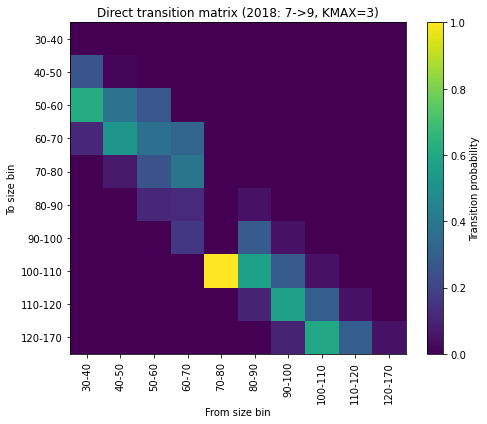

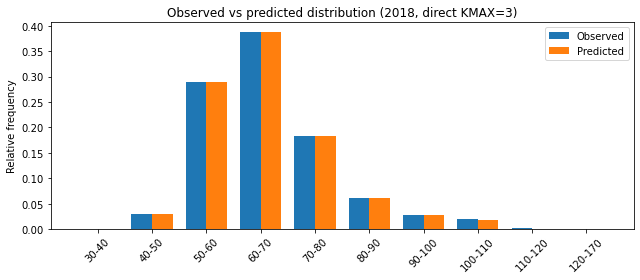


Per-year direct transition diagnostics:
    Year  N_from  N_to  MaxAbsResidual  L2Residual  Success  \
0   1979     175   245        0.000004    0.000005     True   
1   1980     232   332        0.000111    0.000283     True   
2   1981     191   485        0.000034    0.000089     True   
3   1982     117   126        0.041209    0.058816     True   
4   1984      36   118        0.059322    0.059924     True   
5   1986     257   389        0.002571    0.002572     True   
6   1987     392   508        0.057167    0.086182     True   
7   1988     158   317        0.049716    0.082550     True   
8   1989     177   168        0.067897    0.080767     True   
9   1990     228   344        0.002907    0.002907     True   
10  1991     359   241        0.000345    0.000846     True   
11  1992     397   389        0.000153    0.000162     True   
12  1993     429   513        0.000061    0.000065     True   
13  1994     339   454        0.000051    0.000056     True   
14  1995     1

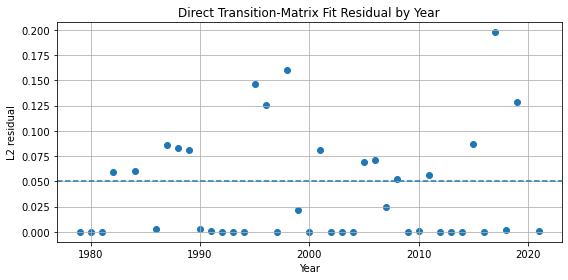

In [23]:
# ============================================================
# ESTIMATE TRANSITION MATRIX
#
# Solve:
#     minimize || f_to - P f_from ||^2
#
# subject to:
#   P[j,i] >= 0
#   P[j,i] = 0 if j < i       (no shrinking)
#   P[j,i] = 0 if j > i+kmax  (limited growth)
#   sum_j P[j,i] <= 1         (allows loss from observed range)
#
# columns = from-bin (earlier month)
# rows    = to-bin   (later month)
# P[j,i] = probability of moving from bin i to bin j
# ============================================================

def estimate_transition_matrix(f_from, f_to, kmax=3):

    f_from = np.asarray(f_from, dtype=float)
    f_to = np.asarray(f_to, dtype=float)

    if f_from.sum() <= 0 or f_to.sum() <= 0:
        raise ValueError("Input vectors must have positive sums.")

    # Defensive normalization
    f_from = f_from / f_from.sum()
    f_to = f_to / f_to.sum()

    n = len(f_from)

    # Allowed transitions mask
    allowed = np.zeros((n, n), dtype=bool)

    for i in range(n):

        jmin = i
        jmax = min(n - 1, i + kmax)

        allowed[jmin:jmax + 1, i] = True

    # Indices of free variables
    idx = [
        (j, i)
        for i in range(n)
        for j in range(n)
        if allowed[j, i]
    ]

    # Initial guess
    p0 = np.zeros(len(idx))

    for k, (j, i) in enumerate(idx):

        if j == i + 2:
            p0[k] = 0.60

        elif j == i + 1:
            p0[k] = 0.30

        elif j == i + 3:
            p0[k] = 0.10

        elif j == i:
            p0[k] = 0.05

    # Convert initial guess to a matrix and scale columns to <= 1
    Pinit = np.zeros((n, n))

    for k, (j, i) in enumerate(idx):
        Pinit[j, i] = p0[k]

    colsum = Pinit.sum(axis=0)

    for i in range(n):

        if colsum[i] > 1.0:
            Pinit[:, i] /= colsum[i]

    p0 = np.array([
        Pinit[j, i]
        for (j, i) in idx
    ])

    def build_P(p):

        P = np.zeros((n, n))

        for val, (j, i) in zip(p, idx):
            P[j, i] = val

        return P

    def obj(p):

        P = build_P(p)

        pred = P @ f_from

        return np.sum((f_to - pred) ** 2)

    # Constraints: for each column i, sum_j P[j,i] <= 1
    cons = []

    for i in range(n):

        inds_i = [
            k
            for k, (j, ii) in enumerate(idx)
            if ii == i
        ]

        if inds_i:

            cons.append({
                "type": "ineq",
                "fun": lambda p, inds=inds_i: 1.0 - np.sum(p[inds])
            })

    bounds = [
        (0.0, 1.0)
        for _ in idx
    ]

    # ------------------------------------------------------------
    # Important:
    # This inverse problem is generally underdetermined.
    # Different transition matrices may produce similar predicted
    # length-frequency distributions while satisfying the biological
    # constraints.
    # ------------------------------------------------------------

    res = minimize(
        obj,
        p0,
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
        options={
            "maxiter": 2000,
            "ftol": 1e-10
        }
    )

    if not res.success:
        raise RuntimeError(
            f"Optimization failed: {res.message}"
        )

    P = build_P(res.x)

    pred = P @ f_from

    colsum = P.sum(axis=0)

    max_abs_residual = np.max(
        np.abs(f_to - pred)
    )

    l2_residual = np.linalg.norm(
        f_to - pred
    )

    return (
        P,
        pred,
        colsum,
        max_abs_residual,
        l2_residual,
        res.success,
        res.message
    )


# ============================================================
# DEMO YEAR: DIRECT JULY -> SEPTEMBER TRANSITION
# ============================================================

demo_year = 2018

f_from, f_to = get_year_vectors(
    demo_year,
    TRANS_FROM,
    TRANS_TO,
    normalize=True
)

f_from_counts, f_to_counts = get_year_vectors(
    demo_year,
    TRANS_FROM,
    TRANS_TO,
    normalize=False
)

if f_from is None or f_to is None:

    raise RuntimeError(
        f"No usable data for demo year {demo_year} "
        f"and months {TRANS_FROM}, {TRANS_TO}."
    )

print(
    f"\nDemo direct transition: "
    f"Year {demo_year}, Month {TRANS_FROM} -> {TRANS_TO}"
)

print("Sample size (from):", int(f_from_counts.sum()))
print("Sample size (to):", int(f_to_counts.sum()))

P, pred, colsum, residual_max, residual_l2, ok, msg = (
    estimate_transition_matrix(
        f_from,
        f_to,
        kmax=KMAX_DIRECT
    )
)

print("\nOptimization success:", ok, "| message:", msg)
print("Max abs residual:", residual_max)
print("L2 residual:", residual_l2)

print(
    "Column sums "
    "(retention by starting bin; <= 1 allows apparent loss):",
    np.round(colsum, 3)
)

P_df = pd.DataFrame(
    P,
    index=labels,
    columns=labels
)

print(
    f"\nDirect transition matrix P for {demo_year} "
    f"(rows=to-bin, cols=from-bin):"
)

print(np.round(P_df, 3))

compare_df = pd.DataFrame({
    "Observed_to": f_to,
    "Predicted_to": pred
}, index=labels)

print(
    f"\nObserved vs predicted distributions "
    f"for year {demo_year}:"
)

print(np.round(compare_df, 4))


# ============================================================
# PLOTS FOR DEMO YEAR
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(
    P,
    aspect="auto"
)

plt.colorbar(
    label="Transition probability"
)

plt.xticks(
    range(len(labels)),
    labels,
    rotation=90
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.title(
    f"Direct transition matrix "
    f"({demo_year}: {TRANS_FROM}->{TRANS_TO}, "
    f"KMAX={KMAX_DIRECT})"
)

plt.xlabel("From size bin")
plt.ylabel("To size bin")

plt.tight_layout()
plt.show()


x = np.arange(len(labels))
w = 0.38

plt.figure(figsize=(9, 4))

plt.bar(x - w / 2,f_to, width=w,label="Observed")

plt.bar(x + w / 2,pred,width=w,label="Predicted")

plt.xticks(x,labels,rotation=45)

plt.ylabel("Relative frequency")

plt.title(
    f"Observed vs predicted distribution "
    f"({demo_year}, direct KMAX={KMAX_DIRECT})"
)

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# ESTIMATE DIRECT JULY -> SEPTEMBER MATRIX FOR EACH YEAR
# ============================================================

P_by_year = {}
diag_rows = []

for y in years:

    fA, fB = get_year_vectors(
        y,
        TRANS_FROM,
        TRANS_TO,
        normalize=True
    )

    fA_counts, fB_counts = get_year_vectors(
        y,
        TRANS_FROM,
        TRANS_TO,
        normalize=False
    )

    if fA is None or fB is None:

        print(
            f"Skipping year {y}: missing or empty data "
            f"for selected months."
        )

        continue

    try:

        (
            P,
            pred,
            colsum,
            residual_max,
            residual_l2,
            ok,
            msg
        ) = estimate_transition_matrix(
            fA,
            fB,
            kmax=KMAX_DIRECT
        )

        P_by_year[y] = {
            "P": P,
            "pred": pred,
            "colsum": colsum,
            "f_from": fA,
            "f_to": fB
        }

        diag_rows.append({
            "Year": y,
            "N_from": int(fA_counts.sum()),
            "N_to": int(fB_counts.sum()),
            "MaxAbsResidual": residual_max,
            "L2Residual": residual_l2,
            "Success": ok,
            "Message": msg
        })

    except RuntimeError as e:

        print(
            f"Year {y}: optimization failed ({e})"
        )


# ============================================================
# DIRECT TRANSITION-MATRIX DIAGNOSTICS
# ============================================================

diag = (
    pd.DataFrame(diag_rows)
    .sort_values("Year")
)

diag["LowSample"] = (
    (diag["N_from"] < 50) |
    (diag["N_to"] < 50)
)

print("\nPer-year direct transition diagnostics:")
print(diag)

print("\nResidual summary:")

print(
    diag[["MaxAbsResidual", "L2Residual"]]
    .describe()
)

print("\nYears with larger L2 residual:")

print(
    diag.loc[
        diag["L2Residual"] > 0.05,
        ["Year", "N_from", "N_to", "L2Residual"]
    ]
)


# ============================================================
# FIT RESIDUALS BY YEAR
# ============================================================

plt.figure(figsize=(8, 4))

plt.scatter(
    diag["Year"],
    diag["L2Residual"]
)

plt.axhline(0.05,linestyle="--")

plt.xlabel("Year")
plt.ylabel("L2 residual")

plt.title(
    "Direct Transition-Matrix Fit Residual by Year"
)

plt.grid(True)
plt.tight_layout()
plt.show()


Number of years used: 40

Years used in mean transition matrix:
[1979, 1980, 1981, 1982, 1984, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021]

Column sums of P_mean:
[0.731 0.95  0.994 1.    1.    0.999 1.    0.95  0.35  0.049]

Mean transition matrix P_mean (rows=to-bin, cols=from-bin):
         30-40  40-50  50-60  60-70  70-80  80-90  90-100  100-110  110-120  \
30-40    0.016  0.000  0.000  0.000  0.000  0.000   0.000     0.00     0.00   
40-50    0.068  0.009  0.000  0.000  0.000  0.000   0.000     0.00     0.00   
50-60    0.320  0.053  0.016  0.000  0.000  0.000   0.000     0.00     0.00   
60-70    0.327  0.363  0.089  0.026  0.000  0.000   0.000     0.00     0.00   
70-80    0.000  0.525  0.354  0.124  0.062  0.000   0.000     0.00     0.00   
80-90    0.000  0.000  0.534  0.491  0.263  0.128   0.000     0.00     0.

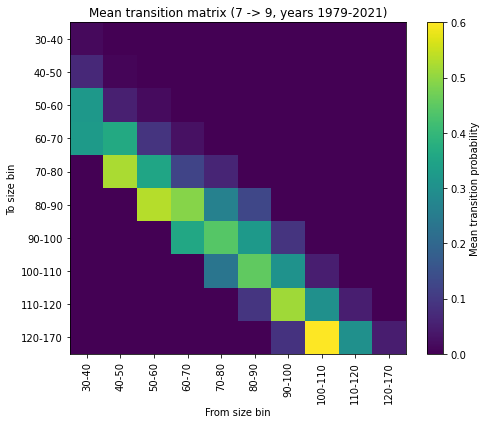

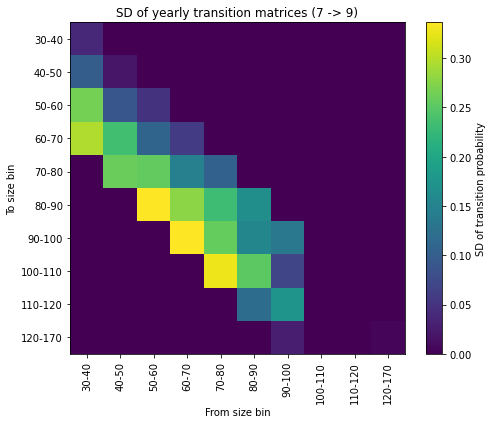

In [14]:
# ============================================================
# MEAN TRANSITION MATRIX ACROSS YEARS
# ============================================================

if len(P_by_year) == 0:
    raise RuntimeError(
        "No yearly transition matrices were estimated."
    )

years_used = sorted(P_by_year.keys())

print("\nNumber of years used:", len(years_used))

print("\nYears used in mean transition matrix:")
print(years_used)

# ------------------------------------------------------------
# Stack yearly transition matrices into a 3D array
#
# axis 0 = year
# axis 1 = to-bin
# axis 2 = from-bin
# ------------------------------------------------------------

P_stack = np.stack(
    [P_by_year[y]["P"] for y in years_used],
    axis=0
)

# ------------------------------------------------------------
# Mean transition matrix
#
# P_mean is an entrywise average of the yearly estimated
# transition matrices. It summarizes the typical transition
# behavior across years.
#
# Important:
# P_mean is NOT obtained by fitting one matrix to pooled data.
# ------------------------------------------------------------

P_mean = P_stack.mean(axis=0)

# ------------------------------------------------------------
# Year-to-year standard deviation
# ------------------------------------------------------------

if len(years_used) > 1:

    P_sd = P_stack.std(axis=0, ddof=1)

else:

    P_sd = np.zeros_like(P_mean)

# ------------------------------------------------------------
# Column sums
#
# Column sums represent the retained probability associated
# with each starting size class.
# Values below 1 allow apparent loss from the observed system.
# ------------------------------------------------------------

print("\nColumn sums of P_mean:")
print(np.round(P_mean.sum(axis=0), 3))

# ------------------------------------------------------------
# Display mean transition matrix
# ------------------------------------------------------------

P_mean_df = pd.DataFrame(
    P_mean,
    index=labels,
    columns=labels
)

print(
    "\nMean transition matrix P_mean "
    "(rows=to-bin, cols=from-bin):"
)

print(np.round(P_mean_df, 3))

# ============================================================
# HEATMAP: MEAN TRANSITION MATRIX
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(P_mean, aspect="auto")

plt.colorbar(label="Mean transition probability")

plt.xticks(
    range(len(labels)),
    labels,
    rotation=90
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.title(
    f"Mean transition matrix "
    f"({TRANS_FROM} -> {TRANS_TO}, "
    f"years {years_used[0]}-{years_used[-1]})"
)

plt.xlabel("From size bin")
plt.ylabel("To size bin")

plt.tight_layout()
plt.show()

# ============================================================
# HEATMAP: STANDARD DEVIATION MATRIX
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(P_sd, aspect="auto")

plt.colorbar(
    label="SD of transition probability"
)

plt.xticks(
    range(len(labels)),
    labels,
    rotation=90
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.title(
    f"SD of yearly transition matrices "
    f"({TRANS_FROM} -> {TRANS_TO})"
)

plt.xlabel("From size bin")
plt.ylabel("To size bin")

plt.tight_layout()
plt.show()

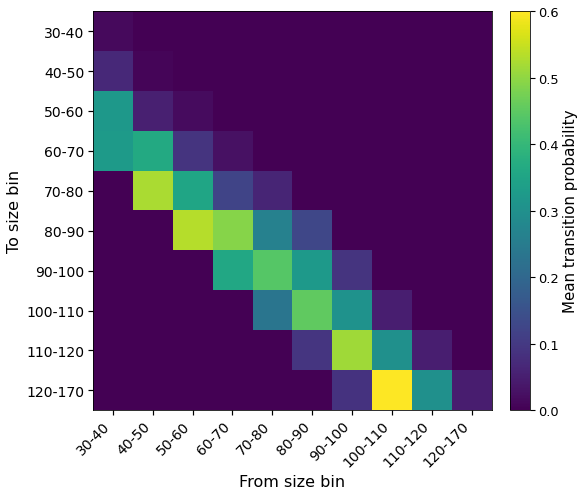

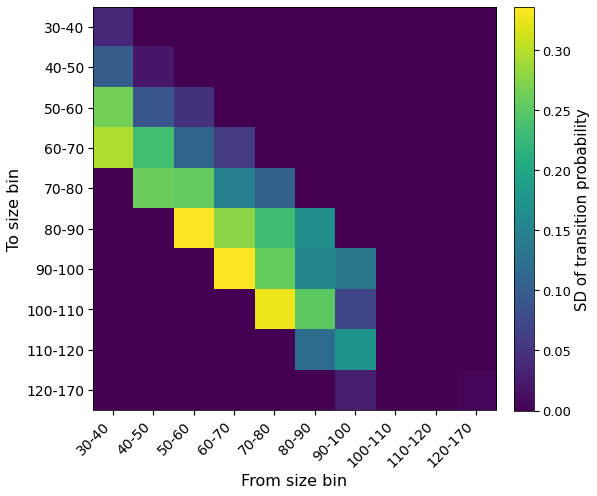

In [15]:
# improved figures
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# PUBLICATION SETTINGS
# ============================================================

label_size = 16
tick_size = 14
cbar_label_size = 15
cbar_tick_size = 13

# ============================================================
# HEATMAP: MEAN TRANSITION MATRIX
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    P_mean,
    aspect="equal",
    cmap="viridis",
    vmin=0,
    vmax=np.nanmax(P_mean)
)

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    "Mean transition probability",
    fontsize=cbar_label_size
)

cbar.ax.tick_params(
    labelsize=cbar_tick_size,
    width=1.1,
    length=5
)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(
    labels,
    rotation=45,
    ha="right",
    fontsize=tick_size
)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(
    labels,
    fontsize=tick_size
)

ax.set_xlabel("From size bin", fontsize=label_size)
ax.set_ylabel("To size bin", fontsize=label_size)

ax.tick_params(
    axis="both",
    width=1.2,
    length=5
)

# Optional concise title
#ax.set_title(
#    f"{TRANS_FROM}–{TRANS_TO} mean transition matrix",
#    fontsize=16,
#    pad=12
#)

fig.tight_layout()

fig.savefig(
    "P_mean_7_9_10bins.pdf",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# HEATMAP: STANDARD DEVIATION MATRIX
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    P_sd,
    aspect="equal",
    cmap="viridis",
    #cmap="magma",
    vmin=0,
    vmax=np.nanmax(P_sd)
)

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    "SD of transition probability",
    fontsize=cbar_label_size
)

cbar.ax.tick_params(
    labelsize=cbar_tick_size,
    width=1.1,
    length=5
)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(
    labels,
    rotation=45,
    ha="right",
    fontsize=tick_size
)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(
    labels,
    fontsize=tick_size
)

ax.set_xlabel("From size bin", fontsize=label_size)
ax.set_ylabel("To size bin", fontsize=label_size)

ax.tick_params(
    axis="both",
    width=1.2,
    length=5
)

#ax.set_title(
#    f"{TRANS_FROM}–{TRANS_TO} transition-matrix variability",
#    fontsize=16,
#    pad=12
#)

fig.tight_layout()

fig.savefig(
    "P_SD_mean_7_9_10bins.pdf",
    bbox_inches="tight"
)

plt.show()


Growth by year:
   Year  MeanGrowth_unconditional_mm  MeanGrowth_conditional_mm  Retention
0  1979                    20.350393                  20.351189   0.999990
1  1980                    15.344412                  15.381914   0.999256
2  1981                    18.307156                  18.320554   0.999749
3  1982                    19.294912                  25.681220   0.909646
4  1984                    21.582237                  26.190447   0.932206

Best growth years:
    Year  MeanGrowth_unconditional_mm  MeanGrowth_conditional_mm  Retention
24  2005                    21.304033                  29.603032   0.883990
34  2015                    18.734832                  28.770770   0.859316
38  2019                    13.083152                  28.137624   0.771905
26  2007                    23.902895                  27.524937   0.942070
30  2011                    21.919966                  27.203787   0.919918

Worst growth years:
    Year  MeanGrowth_unconditional_m

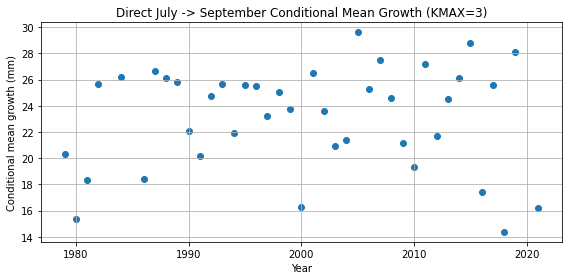

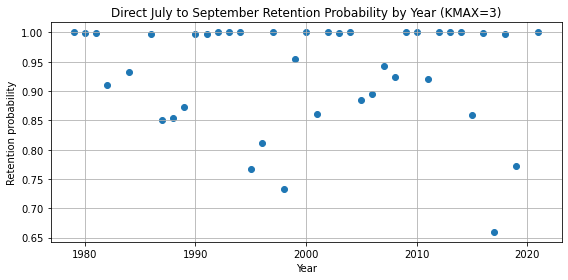

In [16]:
# ============================================================
# COMPUTE MEAN GROWTH AND RETENTION PER YEAR
# ============================================================

# Bin midpoints are used as representative lengths for each size class
bin_mid = np.array([
    (bins[i] + bins[i + 1]) / 2
    for i in range(len(bins) - 1)
])

growth_rows = []

for y in sorted(P_by_year.keys()):

    P = P_by_year[y]["P"]
    f_from = P_by_year[y]["f_from"]

    # --------------------------------------------------------
    # Retention by starting size class
    #
    # colsum[i] = sum over to-bins j of P[j, i]
    #
    # This is the probability that a fish starting in bin i
    # remains within the modeled size range by the later month.
    # --------------------------------------------------------

    colsum = P.sum(axis=0)

    # Overall retention probability:
    # weighted average of class-specific retention probabilities
    retention = np.sum(colsum * f_from)

    # --------------------------------------------------------
    # Expected ending size contribution for each starting class
    #
    # expected_sizes[i] = sum over to-bins j of
    #                     midpoint[j] * P[j, i]
    #
    # This is not conditional on retention because column sums
    # may be less than 1.
    # --------------------------------------------------------

    expected_sizes = P.T @ bin_mid

    # --------------------------------------------------------
    # Unconditional mean growth
    #
    # This combines growth and apparent loss from the modeled
    # size range, so it is less directly biological than the
    # conditional version below.
    # --------------------------------------------------------

    shift_unconditional = expected_sizes - bin_mid

    mean_growth_unconditional = np.sum(
        shift_unconditional * f_from
    )

    # --------------------------------------------------------
    # Conditional expected ending size among retained fish
    #
    # E[L_end | starting bin i, retained]
    #     = expected_sizes[i] / colsum[i]
    # --------------------------------------------------------

    expected_sizes_conditional = np.full_like(
        bin_mid,
        np.nan,
        dtype=float
    )

    positive = colsum > 0

    expected_sizes_conditional[positive] = (
        expected_sizes[positive] / colsum[positive]
    )

    # Conditional growth by starting class
    shift_conditional = np.full_like(
        bin_mid,
        np.nan,
        dtype=float
    )

    shift_conditional[positive] = (
        expected_sizes_conditional[positive]
        - bin_mid[positive]
    )

    # --------------------------------------------------------
    # Mean growth among retained fish only
    #
    # This is usually the most interpretable growth metric.
    # --------------------------------------------------------

    if retention > 0:

        mean_growth_conditional = np.sum(
            f_from[positive]
            * colsum[positive]
            * shift_conditional[positive]
        ) / retention

    else:

        mean_growth_conditional = np.nan

    growth_rows.append({
        "Year": y,
        "MeanGrowth_unconditional_mm": mean_growth_unconditional,
        "MeanGrowth_conditional_mm": mean_growth_conditional,
        "Retention": retention
    })

# ============================================================
# GROWTH SUMMARY TABLE
# ============================================================

growth_df = pd.DataFrame(growth_rows).sort_values("Year")

print("\nGrowth by year:")
print(growth_df.head())

best_growth = (
    growth_df.sort_values(
        "MeanGrowth_conditional_mm",
        ascending=False
    )
    .head(5)
)

worst_growth = (
    growth_df.sort_values(
        "MeanGrowth_conditional_mm"
    )
    .head(5)
)

print("\nBest growth years:")
print(best_growth)

print("\nWorst growth years:")
print(worst_growth)

# ============================================================
# PLOT: CONDITIONAL MEAN GROWTH BY YEAR
# ============================================================

plt.figure(figsize=(8, 4))

plt.scatter(
    growth_df["Year"],
    growth_df["MeanGrowth_conditional_mm"]
)

plt.xlabel("Year")
plt.ylabel("Conditional mean growth (mm)")
plt.title(
    f"Direct July -> September Conditional Mean Growth "
    f"(KMAX={KMAX_DIRECT})"
)

#plt.title("July to September Conditional Mean Growth by Year")

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# PLOT: RETENTION PROBABILITY BY YEAR
# ============================================================

plt.figure(figsize=(8, 4))

plt.scatter(
    growth_df["Year"],
    growth_df["Retention"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Retention probability")
#plt.title("Retention Probability by Year")
plt.title(
    f"Direct July to September Retention Probability by Year "
    f"(KMAX={KMAX_DIRECT})"
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# SIZE-SPECIFIC SUMMARY FROM MEAN TRANSITION MATRIX
# ============================================================

# Bin midpoints are used as representative lengths
bin_mid = np.array([
    (bins[i] + bins[i + 1]) / 2
    for i in range(len(bins) - 1)
])

# ------------------------------------------------------------
# Apparent retention by July size class
#
# retention_mean[i] = sum over September bins j of P_mean[j, i]
# ------------------------------------------------------------

retention_mean = P_mean.sum(axis=0)

# ------------------------------------------------------------
# Conditional expected September size by July size class
#
# E_sept_mean[i] is conditional on remaining within
# the modeled size range.
# ------------------------------------------------------------

E_sept_mean = np.full(
    len(bin_mid),
    np.nan,
    dtype=float
)

for i in range(len(bin_mid)):

    if retention_mean[i] > 0:

        E_sept_mean[i] = (
            np.sum(bin_mid * P_mean[:, i])
            / retention_mean[i]
        )

# ------------------------------------------------------------
# Conditional expected growth by July size class
# ------------------------------------------------------------

growth_mean = E_sept_mean - bin_mid

# ------------------------------------------------------------
# Conditional SD of September size by July size class
# ------------------------------------------------------------

var_sept_mean = np.full(
    len(bin_mid),
    np.nan,
    dtype=float
)

for i in range(len(bin_mid)):

    if retention_mean[i] > 0:

        probs_i = P_mean[:, i] / retention_mean[i]

        var_sept_mean[i] = np.sum(
            ((bin_mid - E_sept_mean[i]) ** 2) * probs_i
        )

sd_sept_mean = np.sqrt(var_sept_mean)

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

summary_mean_df = pd.DataFrame({
    "JulyBin": labels,
    "JulyMid_mm": bin_mid,
    "ExpectedSept_mm": E_sept_mean,
    "ExpectedGrowth_mm": growth_mean,
    "SD_Sept_mm": sd_sept_mean,
    "ApparentRetention": retention_mean
})

print("\nSize-specific summary from mean transition matrix:")
print(summary_mean_df.round(3))




Size-specific summary from mean transition matrix:
   JulyBin  JulyMid_mm  ExpectedSept_mm  ExpectedGrowth_mm  SD_Sept_mm  \
0    30-40        35.0           58.108             23.108       7.292   
1    40-50        45.0           69.784             24.784       6.455   
2    50-60        55.0           79.143             24.143       7.224   
3    60-70        65.0           86.820             21.820       7.451   
4    70-80        75.0           93.449             18.449       8.488   
5    80-90        85.0          100.103             15.103       8.315   
6   90-100        95.0          112.807             17.807      11.917   
7  100-110       105.0          133.421             28.421      15.308   
8  110-120       115.0          140.714             25.714      10.498   
9  120-170       145.0          145.000              0.000       0.000   

   ApparentRetention  
0              0.731  
1              0.950  
2              0.994  
3              1.000  
4              1.0

In [19]:
# ============================================================
# SAVE RESULTS TO FILES
# ============================================================

# ------------------------------------------------------------
# File tag describing the analysis configuration
# ------------------------------------------------------------

transition_tag = (
    f"{TRANS_FROM}to{TRANS_TO}"
    f"_directK{KMAX_DIRECT}"
    f"_bins{BIN_WIDTH}"
)

# ------------------------------------------------------------
# Output file names
# ------------------------------------------------------------

diag_file = (
    f"transition_diagnostics_{transition_tag}.csv"
)

growth_file = (
    f"growth_retention_{transition_tag}.csv"
)

excel_file = (
    f"transition_matrices_{transition_tag}.xlsx"
)

# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

diag.to_csv(
    diag_file,
    index=False
)

growth_df.to_csv(
    growth_file,
    index=False
)

print("\nSaved diagnostics to:")
print(diag_file)

print("\nSaved growth and retention results to:")
print(growth_file)

# ------------------------------------------------------------
# Prepare matrix dataframes
# ------------------------------------------------------------

P_mean_df = pd.DataFrame(
    P_mean,
    index=labels,
    columns=labels
)

P_sd_df = pd.DataFrame(
    P_sd,
    index=labels,
    columns=labels
)

# ------------------------------------------------------------
# Save transition matrices to Excel
# ------------------------------------------------------------

with pd.ExcelWriter(excel_file) as writer:

    # Mean matrix
    P_mean_df.to_excel(
        writer,
        sheet_name="Mean_matrix",
        index_label="To_bin"
    )

    # SD matrix
    P_sd_df.to_excel(
        writer,
        sheet_name="SD_matrix",
        index_label="To_bin"
    )

    # Years included
    pd.DataFrame({
        "Year_used": years_used
    }).to_excel(
        writer,
        sheet_name="Years_used",
        index=False
    )

    # Diagnostics
    diag.to_excel(
        writer,
        sheet_name="Diagnostics",
        index=False
    )

    # Growth and retention summaries
    growth_df.to_excel(
        writer,
        sheet_name="Growth_retention",
        index=False
    )

    # Individual yearly transition matrices
    for y in years_used:

        P_df = pd.DataFrame(
            P_by_year[y]["P"],
            index=labels,
            columns=labels
        )

        P_df.to_excel(
            writer,
            sheet_name=f"P_{y}",
            index_label="To_bin"
        )

print("\nSaved transition matrices and summaries to:")
print(excel_file)


Saved diagnostics to:
transition_diagnostics_7to9_directK3_bins10.csv

Saved growth and retention results to:
growth_retention_7to9_directK3_bins10.csv

Saved transition matrices and summaries to:
transition_matrices_7to9_directK3_bins10.xlsx



Year 2018, monthly transition 7->8 (KMAX_MONTHLY=2)
Sample size from: 318 | Sample size to: 890
Optimization success: True | Optimization terminated successfully
Max abs residual: 1.2373049486542886e-07
L2 residual: 1.6748505235699746e-07

Monthly transition matrix for 2018: 7->8 (KMAX=2)
(rows = to-bin, columns = from-bin)
         30-40  40-50  50-60  60-70  70-80  80-90  90-100  100-110  110-120  \
30-40    0.159  0.000  0.000  0.000  0.000   0.00    0.00     0.00     0.00   
40-50    0.308  0.447  0.000  0.000  0.000   0.00    0.00     0.00     0.00   
50-60    0.533  0.382  0.613  0.000  0.000   0.00    0.00     0.00     0.00   
60-70    0.000  0.170  0.338  0.728  0.000   0.00    0.00     0.00     0.00   
70-80    0.000  0.000  0.049  0.233  0.343   0.00    0.00     0.00     0.00   
80-90    0.000  0.000  0.000  0.040  0.538   0.05    0.00     0.00     0.00   
90-100   0.000  0.000  0.000  0.000  0.119   0.30    0.05     0.00     0.00   
100-110  0.000  0.000  0.000  0.000  0.00

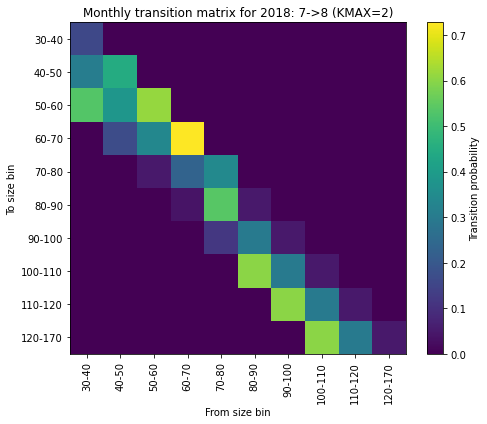


Year 2018, monthly transition 8->9 (KMAX_MONTHLY=2)
Sample size from: 890 | Sample size to: 648
Optimization success: True | Optimization terminated successfully
Max abs residual: 0.0012531076792989331
L2 residual: 0.0017704652920077215

Monthly transition matrix for 2018: 8->9 (KMAX=2)
(rows = to-bin, columns = from-bin)
         30-40  40-50  50-60  60-70  70-80  80-90  90-100  100-110  110-120  \
30-40    0.000  0.000  0.000  0.000  0.000    0.0   0.000     0.00     0.00   
40-50    0.306  0.135  0.000  0.000  0.000    0.0   0.000     0.00     0.00   
50-60    0.615  0.378  0.514  0.000  0.000    0.0   0.000     0.00     0.00   
60-70    0.000  0.487  0.346  0.503  0.000    0.0   0.000     0.00     0.00   
70-80    0.000  0.000  0.139  0.368  0.203    0.0   0.000     0.00     0.00   
80-90    0.000  0.000  0.000  0.129  0.341    0.0   0.000     0.00     0.00   
90-100   0.000  0.000  0.000  0.000  0.434    0.0   0.000     0.00     0.00   
100-110  0.000  0.000  0.000  0.000  0.000 

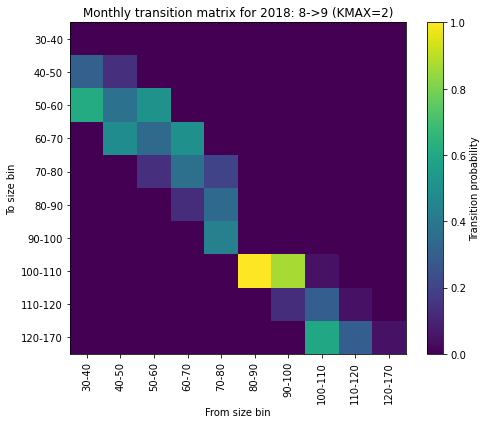


Composed transition matrix for 2018: 7->9 via 7->8 and 8->9 (monthly KMAX=2)
(rows = to-bin, columns = from-bin)
         30-40  40-50  50-60  60-70  70-80  80-90  90-100  100-110  110-120  \
30-40    0.000  0.000  0.000  0.000  0.000  0.000   0.000    0.000    0.000   
40-50    0.090  0.060  0.000  0.000  0.000  0.000   0.000    0.000    0.000   
50-60    0.488  0.366  0.315  0.000  0.000  0.000   0.000    0.000    0.000   
60-70    0.335  0.436  0.382  0.366  0.000  0.000   0.000    0.000    0.000   
70-80    0.074  0.116  0.220  0.315  0.070  0.000   0.000    0.000    0.000   
80-90    0.000  0.022  0.060  0.173  0.117  0.000   0.000    0.000    0.000   
90-100   0.000  0.000  0.021  0.101  0.149  0.000   0.000    0.000    0.000   
100-110  0.000  0.000  0.000  0.040  0.641  0.341   0.059    0.003    0.000   
110-120  0.000  0.000  0.000  0.000  0.015  0.219   0.126    0.030    0.003   
120-170  0.000  0.000  0.000  0.000  0.000  0.360   0.360    0.150    0.030   

         120-170

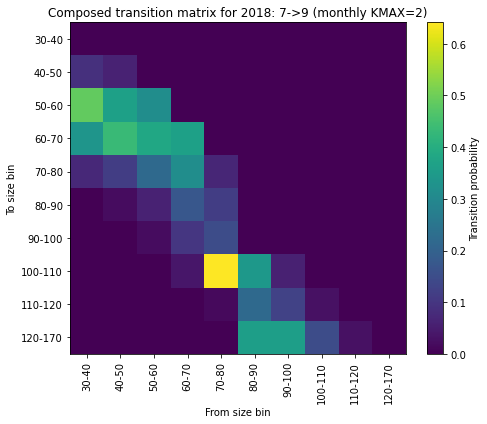


Observed vs composed-predicted September distribution for 2018
         Observed_Sept  Predicted_Sept_Composed
30-40           0.0000                   0.0000
40-50           0.0293                   0.0293
50-60           0.2886                   0.2886
60-70           0.3873                   0.3873
70-80           0.1836                   0.1836
80-90           0.0617                   0.0617
90-100          0.0278                   0.0278
100-110         0.0201                   0.0188
110-120         0.0015                   0.0003
120-170         0.0000                   0.0000


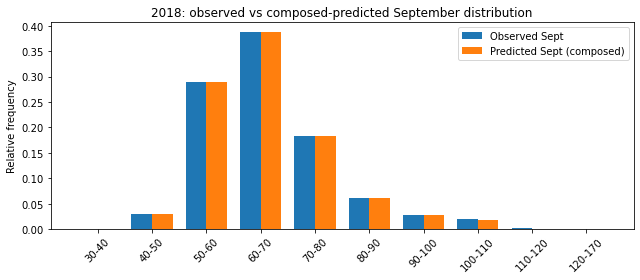

In [28]:
# ============================================================
# MONTHLY TRANSITION MATRICES FOR A GIVEN YEAR
# ============================================================

def compute_monthly_transitions_for_year(year, month_pairs, kmax):
   
    # Compute transition matrices for selected month pairs for one year.

    # Here kmax should usually be KMAX_MONTHLY, because these are one-month transitions such as July->August and
    # August->September.
   

    results = {}

    for m_from, m_to in month_pairs:

        # Normalized vectors for fitting
        f_from, f_to = get_year_vectors(
            year,
            m_from,
            m_to,
            normalize=True
        )

        # Raw counts for reporting
        f_from_counts, f_to_counts = get_year_vectors(
            year,
            m_from,
            m_to,
            normalize=False
        )

        if f_from is None or f_to is None:

            results[(m_from, m_to)] = None
            continue

        (
            P,
            pred,
            colsum,
            residual_max,
            residual_l2,
            ok,
            msg
        ) = estimate_transition_matrix(
            f_from,
            f_to,
            kmax=kmax
        )

        results[(m_from, m_to)] = {
            "P": P,
            "pred": pred,
            "colsum": colsum,
            "residual_max": residual_max,
            "residual_l2": residual_l2,
            "success": ok,
            "message": msg,
            "f_from": f_from,
            "f_to": f_to,
            "N_from": int(f_from_counts.sum()),
            "N_to": int(f_to_counts.sum())
        }

    return results


# ============================================================
# COMPOSE TRANSITION MATRICES
# ============================================================

def compose_transition_matrices(P_list):
   
   # Compose matrices in chronological order.

    
    if len(P_list) == 0:

        raise ValueError(
            "P_list must contain at least one matrix."
        )

    P_comp = P_list[0]

    for Pnext in P_list[1:]:

        P_comp = Pnext @ P_comp

    return P_comp


# ============================================================
# PRINT TRANSITION MATRIX
# ============================================================

def print_transition_matrix(P, labels, title="Transition matrix"):

    P_df = pd.DataFrame(
        P,
        index=labels,
        columns=labels
    )

    print(f"\n{title}")
    print("(rows = to-bin, columns = from-bin)")
    print(np.round(P_df, 3))


# ============================================================
# PLOT TRANSITION MATRIX HEATMAP
# ============================================================

def plot_transition_matrix(
    P,
    labels,
    title="Transition matrix",
    cmap="viridis"
):

    plt.figure(figsize=(7, 6))

    plt.imshow(
        P,
        aspect="auto",
        cmap=cmap
    )

    plt.colorbar(
        label="Transition probability"
    )

    plt.xticks(
        range(len(labels)),
        labels,
        rotation=90
    )

    plt.yticks(
        range(len(labels)),
        labels
    )

    plt.xlabel("From size bin")
    plt.ylabel("To size bin")
    plt.title(title)

    plt.tight_layout()
    plt.show()


# ============================================================
# EXAMPLE FOR ONE YEAR: MONTHLY TRANSITIONS
# ============================================================

YEAR_TO_ANALYZE = 2018

month_pairs = [
    (7, 8),
    (8, 9)
]

results_year = compute_monthly_transitions_for_year(
    YEAR_TO_ANALYZE,
    month_pairs=month_pairs,
    kmax=KMAX_MONTHLY
)

# Print diagnostics
for pair, res in results_year.items():

    if res is None:

        print(
            f"\nYear {YEAR_TO_ANALYZE}, "
            f"transition {pair[0]}->{pair[1]}: missing data"
        )

        continue

    print(
        f"\nYear {YEAR_TO_ANALYZE}, "
        f"monthly transition {pair[0]}->{pair[1]} "
        f"(KMAX_MONTHLY={KMAX_MONTHLY})"
    )

    print(
        "Sample size from:",
        res["N_from"],
        "| Sample size to:",
        res["N_to"]
    )

    print(
        "Optimization success:",
        res["success"],
        "|",
        res["message"]
    )

    print("Max abs residual:", res["residual_max"])
    print("L2 residual:", res["residual_l2"])

    print_transition_matrix(
        res["P"],
        labels,
        title=(
            f"Monthly transition matrix for "
            f"{YEAR_TO_ANALYZE}: "
            f"{pair[0]}->{pair[1]} "
            f"(KMAX={KMAX_MONTHLY})"
        )
    )

    plot_transition_matrix(
        res["P"],
        labels,
        title=(
            f"Monthly transition matrix for "
            f"{YEAR_TO_ANALYZE}: "
            f"{pair[0]}->{pair[1]} "
            f"(KMAX={KMAX_MONTHLY})"
        )
    )


# ============================================================
# COMPOSE JULY -> SEPTEMBER FROM MONTHLY MATRICES
# ============================================================

if (
    results_year[(7, 8)] is not None and
    results_year[(8, 9)] is not None
):

    P_7_8 = results_year[(7, 8)]["P"]
    P_8_9 = results_year[(8, 9)]["P"]

    P_7_9_comp = compose_transition_matrices(
        [P_7_8, P_8_9]
    )

    print_transition_matrix(
        P_7_9_comp,
        labels,
        title=(
            f"Composed transition matrix for "
            f"{YEAR_TO_ANALYZE}: 7->9 via 7->8 and 8->9 "
            f"(monthly KMAX={KMAX_MONTHLY})"
        )
    )

    plot_transition_matrix(
        P_7_9_comp,
        labels,
        title=(
            f"Composed transition matrix for "
            f"{YEAR_TO_ANALYZE}: 7->9 "
            f"(monthly KMAX={KMAX_MONTHLY})"
        )
    )

    # Compare predicted September distribution from composition
    f7, f9 = get_year_vectors(
        YEAR_TO_ANALYZE,
        7,
        9,
        normalize=True
    )

    pred9_comp = P_7_9_comp @ f7

    compare_df = pd.DataFrame({
        "Observed_Sept": f9,
        "Predicted_Sept_Composed": pred9_comp
    }, index=labels)

    print(
        f"\nObserved vs composed-predicted September "
        f"distribution for {YEAR_TO_ANALYZE}"
    )

    print(np.round(compare_df, 4))

    x = np.arange(len(labels))
    w = 0.38

    plt.figure(figsize=(9, 4))

    plt.bar(x - w / 2,f9,width=w,label="Observed Sept")

    plt.bar(x + w / 2,pred9_comp,width=w,label="Predicted Sept (composed)")

    plt.xticks(x,labels,rotation=45)

    plt.ylabel("Relative frequency")

    plt.title(
        f"{YEAR_TO_ANALYZE}: observed vs composed-predicted "
        f"September distribution"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

else:

    print(
        f"\nCannot compose 7->9 for year {YEAR_TO_ANALYZE}: "
        f"missing 7->8 or 8->9 matrix."
    )


Composed transition matrix for 2018: 7->9 (monthly KMAX=2)
(rows = to-bin, columns = from-bin)
         30-40  40-50  50-60  60-70  70-80  80-90  90-100  100-110  110-120  \
30-40    0.000  0.000  0.000  0.000  0.000  0.000   0.000    0.000    0.000   
40-50    0.090  0.060  0.000  0.000  0.000  0.000   0.000    0.000    0.000   
50-60    0.488  0.366  0.315  0.000  0.000  0.000   0.000    0.000    0.000   
60-70    0.335  0.436  0.382  0.366  0.000  0.000   0.000    0.000    0.000   
70-80    0.074  0.116  0.220  0.315  0.070  0.000   0.000    0.000    0.000   
80-90    0.000  0.022  0.060  0.173  0.117  0.000   0.000    0.000    0.000   
90-100   0.000  0.000  0.021  0.101  0.149  0.000   0.000    0.000    0.000   
100-110  0.000  0.000  0.000  0.040  0.641  0.341   0.059    0.003    0.000   
110-120  0.000  0.000  0.000  0.000  0.015  0.219   0.126    0.030    0.003   
120-170  0.000  0.000  0.000  0.000  0.000  0.360   0.360    0.150    0.030   

         120-170  
30-40      0.00

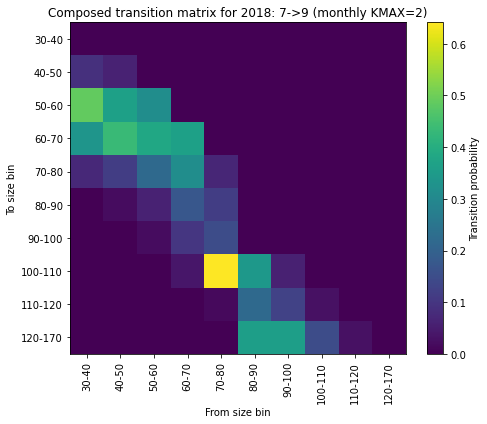


Direct transition 7->9 for 2018 (KMAX_DIRECT=3)
Sample size from: 318 | Sample size to: 648
Optimization success: True | Optimization terminated successfully
Max abs residual: 0.0015432098765432098
L2 residual: 0.001951068870268602

Direct transition matrix for 2018: 7->9 (KMAX=3)
(rows = to-bin, columns = from-bin)
         30-40  40-50  50-60  60-70  70-80  80-90  90-100  100-110  110-120  \
30-40    0.000  0.000  0.000  0.000    0.0  0.000   0.000     0.00     0.00   
40-50    0.265  0.019  0.000  0.000    0.0  0.000   0.000     0.00     0.00   
50-60    0.621  0.380  0.270  0.000    0.0  0.000   0.000     0.00     0.00   
60-70    0.111  0.525  0.364  0.328    0.0  0.000   0.000     0.00     0.00   
70-80    0.000  0.070  0.254  0.384    0.0  0.000   0.000     0.00     0.00   
80-90    0.000  0.000  0.111  0.122    0.0  0.048   0.000     0.00     0.00   
90-100   0.000  0.000  0.000  0.164    0.0  0.286   0.048     0.00     0.00   
100-110  0.000  0.000  0.000  0.000    1.0  0.571

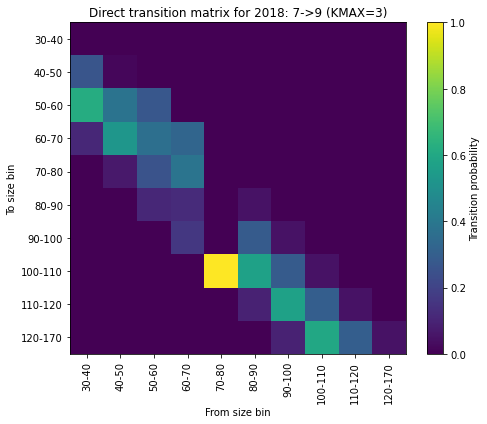


Direct minus composed transition matrix for 2018: 7->9
(rows = to-bin, columns = from-bin)
         30-40  40-50  50-60  60-70  70-80  80-90  90-100  100-110  110-120  \
30-40    0.000  0.000  0.000  0.000  0.000  0.000   0.000    0.000    0.000   
40-50    0.175 -0.041  0.000  0.000  0.000  0.000   0.000    0.000    0.000   
50-60    0.133  0.015 -0.045  0.000  0.000  0.000   0.000    0.000    0.000   
60-70   -0.223  0.089 -0.018 -0.038  0.000  0.000   0.000    0.000    0.000   
70-80   -0.074 -0.046  0.034  0.068 -0.070  0.000   0.000    0.000    0.000   
80-90    0.000 -0.022  0.051 -0.051 -0.117  0.048   0.000    0.000    0.000   
90-100   0.000  0.000 -0.021  0.063 -0.149  0.286   0.048    0.000    0.000   
100-110  0.000  0.000  0.000 -0.040  0.359  0.230   0.227    0.048    0.000   
110-120  0.000  0.000  0.000  0.000 -0.015 -0.123   0.445    0.270    0.048   
120-170  0.000  0.000  0.000  0.000  0.000 -0.360  -0.265    0.450    0.270   

         120-170  
30-40      0.000  


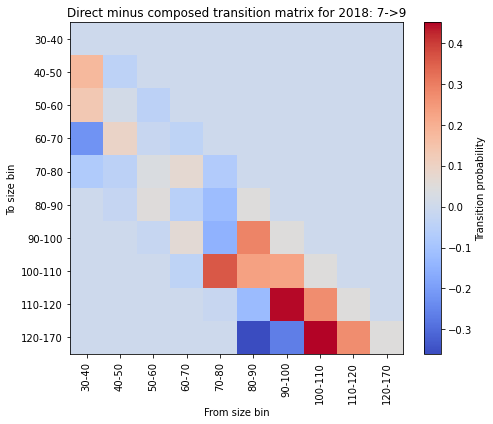


Composed September prediction diagnostics:
Max abs residual: 0.0012531101138398516
L2 residual: 0.0017705234412456312

Difference between direct and composed September predictions:
0.000296

Observed vs predicted September distribution for 2018
         Observed_Sept  Predicted_Sept_Direct  Predicted_Sept_Composed
30-40           0.0000                 0.0000                   0.0000
40-50           0.0293                 0.0293                   0.0293
50-60           0.2886                 0.2886                   0.2886
60-70           0.3873                 0.3873                   0.3873
70-80           0.1836                 0.1836                   0.1836
80-90           0.0617                 0.0617                   0.0617
90-100          0.0278                 0.0278                   0.0278
100-110         0.0201                 0.0189                   0.0188
110-120         0.0015                 0.0000                   0.0003
120-170         0.0000                 0.000

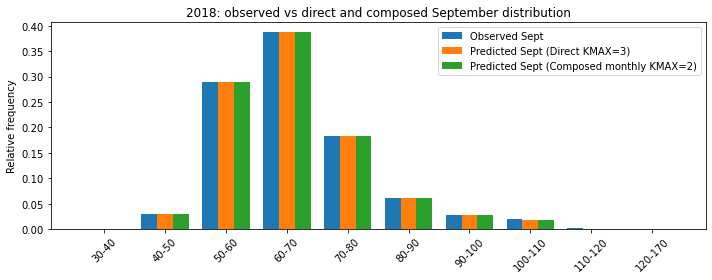


Retention comparison:
Direct 7->9 (KMAX=3): 0.9973
Composed 7->8->9 (monthly KMAX=2): 0.9975
Difference: -0.0002

Conditional mean growth comparison (mm):
Direct 7->9 (KMAX=3): 14.386
Composed 7->8->9 (monthly KMAX=2): 14.408
Difference (mm): -0.022


In [29]:
# ============================================================
# HELPER FUNCTION: RETENTION AND CONDITIONAL GROWTH
# ============================================================

def summarize_transition_growth(P, f_from, bin_mid):
    
   # Compute retention and conditional mean growth for one transition matrix.
    

    colsum = P.sum(axis=0)

    retention = np.sum(colsum * f_from)

    weighted_end = P.T @ bin_mid

    expected_end_cond = np.full(
        len(bin_mid),
        np.nan
    )

    positive = colsum > 0

    expected_end_cond[positive] = (
        weighted_end[positive] / colsum[positive]
    )

    growth_by_bin_cond = np.full(
        len(bin_mid),
        np.nan
    )

    growth_by_bin_cond[positive] = (
        expected_end_cond[positive]
        - bin_mid[positive]
    )

    if retention > 0:

        mean_growth_conditional = np.sum(
            f_from[positive]
            * colsum[positive]
            * growth_by_bin_cond[positive]
        ) / retention

    else:

        mean_growth_conditional = np.nan

    return {
        "colsum": colsum,
        "retention": retention,
        "mean_growth_conditional": mean_growth_conditional
    }


# ============================================================
# HELPER FUNCTION: MATRIX DIFFERENCE DIAGNOSTICS
# ============================================================

def compute_matrix_difference_metrics(P_direct, P_comp):
   
    # Compute summary diagnostics comparing two matrices.
    

    diff_matrix = P_direct - P_comp

    diff_abs = np.abs(diff_matrix)

    max_diff = np.max(diff_abs)

    fro_diff = np.linalg.norm(diff_matrix)

    nonzero_mask = (
        (P_direct != 0) |
        (P_comp != 0)
    )

    mean_abs_diff = np.mean(
        diff_abs[nonzero_mask]
    )

    i_max, j_max = np.unravel_index(
        np.argmax(diff_abs),
        diff_abs.shape
    )

    return {
        "diff_matrix": diff_matrix,
        "max_diff": max_diff,
        "fro_diff": fro_diff,
        "mean_abs_diff": mean_abs_diff,
        "i_max": i_max,
        "j_max": j_max
    }


# ============================================================
# DEMONSTRATION FOR A SINGLE YEAR:
# DIRECT VS COMPOSED JULY -> SEPTEMBER TRANSITION
#
# Direct approach:
#   Estimate one July->September matrix directly using
#   KMAX_DIRECT.
#
# Composed approach:
#   Estimate July->August and August->September matrices using
#   KMAX_MONTHLY, then compose them:
#
#       P_7_9_composed = P_8_9 @ P_7_8
#
# The two approaches need not produce identical matrices,
# because they use different temporal information and solve
# related but distinct inverse problems.
# ============================================================

if (
    results_year[(7, 8)] is not None and
    results_year[(8, 9)] is not None
):

    # --------------------------------------------------------
    # BUILD COMPOSED MATRIX
    #
    # Matrix multiplication order matters:
    #
    # f8 = P_7_8 @ f7
    # f9 = P_8_9 @ f8
    #
    # therefore:
    #
    # f9 = P_8_9 @ P_7_8 @ f7
    # --------------------------------------------------------

    P_7_8 = results_year[(7, 8)]["P"]
    P_8_9 = results_year[(8, 9)]["P"]

    P_7_9_comp = compose_transition_matrices(
        [P_7_8, P_8_9]
    )

    print_transition_matrix(
        P_7_9_comp,
        labels,
        title=(
            f"Composed transition matrix for "
            f"{YEAR_TO_ANALYZE}: 7->9 "
            f"(monthly KMAX={KMAX_MONTHLY})"
        )
    )

    plot_transition_matrix(
        P_7_9_comp,
        labels,
        title=(
            f"Composed transition matrix for "
            f"{YEAR_TO_ANALYZE}: 7->9 "
            f"(monthly KMAX={KMAX_MONTHLY})"
        )
    )

    # --------------------------------------------------------
    # ESTIMATE DIRECT MATRIX
    # --------------------------------------------------------

    f7, f9 = get_year_vectors(
        YEAR_TO_ANALYZE,
        7,
        9,
        normalize=True
    )

    f7_counts, f9_counts = get_year_vectors(
        YEAR_TO_ANALYZE,
        7,
        9,
        normalize=False
    )

    if f7 is None or f9 is None:

        print(
            f"\nCannot estimate direct 7->9 matrix "
            f"for year {YEAR_TO_ANALYZE}: missing data."
        )

    else:

        (
            P_7_9_direct,
            pred9_direct,
            colsum_direct,
            residual_max_direct,
            residual_l2_direct,
            ok_direct,
            msg_direct
        ) = estimate_transition_matrix(
            f7,
            f9,
            kmax=KMAX_DIRECT
        )

        print(
            f"\nDirect transition 7->9 "
            f"for {YEAR_TO_ANALYZE} "
            f"(KMAX_DIRECT={KMAX_DIRECT})"
        )

        print(
            "Sample size from:",
            int(f7_counts.sum()),
            "| Sample size to:",
            int(f9_counts.sum())
        )

        print(
            "Optimization success:",
            ok_direct,
            "|",
            msg_direct
        )

        print("Max abs residual:", residual_max_direct)
        print("L2 residual:", residual_l2_direct)

        print_transition_matrix(
            P_7_9_direct,
            labels,
            title=(
                f"Direct transition matrix for "
                f"{YEAR_TO_ANALYZE}: 7->9 "
                f"(KMAX={KMAX_DIRECT})"
            )
        )

        plot_transition_matrix(
            P_7_9_direct,
            labels,
            title=(
                f"Direct transition matrix for "
                f"{YEAR_TO_ANALYZE}: 7->9 "
                f"(KMAX={KMAX_DIRECT})"
            )
        )

        # ----------------------------------------------------
        # COMPARE MATRICES
        #
        # Large matrix differences do not necessarily imply
        # large differences in predicted September distributions.
        # Multiple transition structures may produce similar
        # projected size distributions.
        # ----------------------------------------------------

        metrics = compute_matrix_difference_metrics(
            P_7_9_direct,
            P_7_9_comp
        )

        diff_matrix = metrics["diff_matrix"]

        print_transition_matrix(
            diff_matrix,
            labels,
            title=(
                f"Direct minus composed transition matrix "
                f"for {YEAR_TO_ANALYZE}: 7->9"
            )
        )

        print("\nMatrix-difference diagnostics:")

        print(
            "Max absolute difference:",
            round(metrics["max_diff"], 4)
        )

        print(
            "Frobenius norm:",
            round(metrics["fro_diff"], 4)
        )

        print(
            "Mean absolute difference over active entries:",
            round(metrics["mean_abs_diff"], 4)
        )

        i_max = metrics["i_max"]
        j_max = metrics["j_max"]

        print("\nLargest difference at:")
        print("To bin:", labels[i_max])
        print("From bin:", labels[j_max])

        print(
            "Direct probability:",
            round(P_7_9_direct[i_max, j_max],4)
        )

        print(
            "Composed probability:",
            round(P_7_9_comp[i_max, j_max],4)
        )

        plot_transition_matrix(
            diff_matrix,
            labels,
            title=(
                f"Direct minus composed transition matrix "
                f"for {YEAR_TO_ANALYZE}: 7->9"),
            cmap="coolwarm"
        )

        # ----------------------------------------------------
        # COMPARE SEPTEMBER PREDICTIONS
        # ----------------------------------------------------

        pred9_comp = P_7_9_comp @ f7

        residual_max_comp = np.max(
            np.abs(f9 - pred9_comp)
        )

        residual_l2_comp = np.linalg.norm(
            f9 - pred9_comp
        )

        prediction_diff = np.linalg.norm(
            pred9_direct - pred9_comp
        )

        print("\nComposed September prediction diagnostics:")
        print("Max abs residual:", residual_max_comp)
        print("L2 residual:", residual_l2_comp)

        print(
            "\nDifference between direct and "
            "composed September predictions:"
        )

        print(round(prediction_diff, 6))

        compare_df = pd.DataFrame({
            "Observed_Sept": f9,
            "Predicted_Sept_Direct": pred9_direct,
            "Predicted_Sept_Composed": pred9_comp
        }, index=labels)

        print(
            f"\nObserved vs predicted September "
            f"distribution for {YEAR_TO_ANALYZE}"
        )

        print(np.round(compare_df, 4))

        x = np.arange(len(labels))
        w = 0.26

        plt.figure(figsize=(10, 4))

        plt.bar(x - w,f9, width=w,label="Observed Sept")

        plt.bar(
            x,
            pred9_direct,
            width=w,
            label=(
                f"Predicted Sept "
                f"(Direct KMAX={KMAX_DIRECT})"
            )
        )

        plt.bar(
            x + w,
            pred9_comp,
            width=w,
            label=(
                f"Predicted Sept "
                f"(Composed monthly KMAX={KMAX_MONTHLY})"
            )
        )

        plt.xticks(
            x,
            labels,
            rotation=45
        )

        plt.ylabel("Relative frequency")

        plt.title(
            f"{YEAR_TO_ANALYZE}: observed vs direct and composed "
            f"September distribution"
        )

        plt.legend()
        plt.tight_layout()
        plt.show()

        # ----------------------------------------------------
        # COMPARE BIOLOGICAL SUMMARIES
        # ----------------------------------------------------

        bin_mid = np.array([
            (bins[i] + bins[i + 1]) / 2
            for i in range(len(bins) - 1)
        ])

        summary_direct = summarize_transition_growth(
            P_7_9_direct,
            f7,
            bin_mid
        )

        summary_comp = summarize_transition_growth(
            P_7_9_comp,
            f7,
            bin_mid
        )

        print("\nRetention comparison:")

        print(f"Direct 7->9 "
            f"(KMAX={KMAX_DIRECT}):",
            round(summary_direct["retention"],4))

        print(
            f"Composed 7->8->9 "
            f"(monthly KMAX={KMAX_MONTHLY}):",
            round(summary_comp["retention"],4)
        )

        print(
            "Difference:",
            round( summary_direct["retention"]- summary_comp["retention"],4)
        )

        print("\nConditional mean growth comparison (mm):")

        print(
            f"Direct 7->9 "
            f"(KMAX={KMAX_DIRECT}):",
            round(summary_direct["mean_growth_conditional"],3)
        )

        print(
            f"Composed 7->8->9 "
            f"(monthly KMAX={KMAX_MONTHLY}):",
            round(summary_comp["mean_growth_conditional"],3)
        )

        print(
            "Difference (mm):",
            round(summary_direct["mean_growth_conditional"]- summary_comp["mean_growth_conditional"],3)
        )

else:

    print(
        f"\nCannot compare direct and composed "
        f"7->9 for year {YEAR_TO_ANALYZE}: "
        f"missing 7->8 or 8->9 matrix."
    )

In [30]:
# ============================================================
# DIRECT VS COMPOSED COMPARISON ACROSS ALL YEARS
#
# Direct approach:
#   One July->September matrix estimated using KMAX_DIRECT
#
# Composed approach:
#   July->August and August->September matrices estimated
#   using KMAX_MONTHLY, then composed:
#
#       P_7_9_comp = P_8_9 @ P_7_8
#
# This section compares:
#   - matrix differences,
#   - September predictions,
#   - retention,
#   - conditional mean growth.
# ============================================================

comparison_rows = []

bin_mid = np.array([
    (bins[i] + bins[i + 1]) / 2
    for i in range(len(bins) - 1)
])

for y in years:

    # --------------------------------------------------------
    # ESTIMATE MONTHLY TRANSITIONS
    # --------------------------------------------------------

    monthly_results = compute_monthly_transitions_for_year(
        y,
        month_pairs=[(7, 8), (8, 9)],
        kmax=KMAX_MONTHLY
    )

    if (
        monthly_results[(7, 8)] is None or
        monthly_results[(8, 9)] is None
    ):
        continue

    P_7_8 = monthly_results[(7, 8)]["P"]
    P_8_9 = monthly_results[(8, 9)]["P"]

    # --------------------------------------------------------
    # COMPOSE JULY -> SEPTEMBER TRANSITION
    # --------------------------------------------------------

    P_7_9_comp = compose_transition_matrices(
        [P_7_8, P_8_9]
    )

    # --------------------------------------------------------
    # ESTIMATE DIRECT JULY -> SEPTEMBER TRANSITION
    # --------------------------------------------------------

    f7, f9 = get_year_vectors(y,7,9,normalize=True)

    f7_counts, f9_counts = get_year_vectors(y,7,9,normalize=False)

    if f7 is None or f9 is None:
        continue

    try:

        (
            P_7_9_direct,
            pred9_direct,
            colsum_direct,
            residual_max_direct,
            residual_l2_direct,
            ok,
            msg
        ) = estimate_transition_matrix(
            f7,
            f9,
            kmax=KMAX_DIRECT
        )

    except RuntimeError:

        continue

    if not ok:
        continue

    # --------------------------------------------------------
    # MATRIX-DIFFERENCE DIAGNOSTICS
    # --------------------------------------------------------

    metrics = compute_matrix_difference_metrics(
        P_7_9_direct,
        P_7_9_comp
    )

    # --------------------------------------------------------
    # COMPARE SEPTEMBER PREDICTIONS
    # --------------------------------------------------------

    pred9_comp = P_7_9_comp @ f7

    residual_max_comp = np.max(
        np.abs(f9 - pred9_comp)
    )

    residual_l2_comp = np.linalg.norm(
        f9 - pred9_comp
    )

    prediction_difference = np.linalg.norm(
        pred9_direct - pred9_comp
    )

    # --------------------------------------------------------
    # COMPARE BIOLOGICAL SUMMARIES
    # --------------------------------------------------------

    summary_direct = summarize_transition_growth(
        P_7_9_direct,
        f7,
        bin_mid
    )

    summary_comp = summarize_transition_growth(
        P_7_9_comp,
        f7,
        bin_mid
    )

    retention_diff = (
        summary_direct["retention"]
        - summary_comp["retention"]
    )

    growth_diff = (
        summary_direct["mean_growth_conditional"]
        - summary_comp["mean_growth_conditional"]
    )

    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    comparison_rows.append({

        "Year": y,

        "N_July": int(f7_counts.sum()),
        "N_Sept": int(f9_counts.sum()),

        "KMAX_DIRECT": KMAX_DIRECT,
        "KMAX_MONTHLY": KMAX_MONTHLY,

        # Matrix differences
        "MaxMatrixDifference": metrics["max_diff"],
        "FrobeniusDifference": metrics["fro_diff"],
        "MeanActiveDifference": metrics["mean_abs_diff"],

        # Direct residuals
        "Direct_MaxResidual": residual_max_direct,
        "Direct_L2Residual": residual_l2_direct,

        # Composed residuals
        "Composed_MaxResidual": residual_max_comp,
        "Composed_L2Residual": residual_l2_comp,

        # Difference between predicted September distributions
        "PredictionDifference": prediction_difference,

        # Retention
        "Retention_Direct": summary_direct["retention"],
        "Retention_Composed": summary_comp["retention"],
        "RetentionDifference": retention_diff,

        # Conditional mean growth
        "Growth_Direct_Conditional_mm": (
            summary_direct["mean_growth_conditional"]
        ),

        "Growth_Composed_Conditional_mm": (
            summary_comp["mean_growth_conditional"]
        ),

        "GrowthDifference_mm": growth_diff
    })


# ============================================================
# BUILD SUMMARY TABLE
# ============================================================

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values("Year")
)

print(
    "\nDirect vs composed comparison across years:"
)

print(comparison_df.head())

print("\nSummary statistics:")
print(comparison_df.describe())


# ============================================================
# YEARS WITH LARGEST MATRIX DIFFERENCES
# ============================================================

print(
    "\nYears with largest maximum matrix differences:"
)

print(
    comparison_df.sort_values(
        "MaxMatrixDifference",
        ascending=False
    )
    [[
        "Year",
        "N_July",
        "N_Sept",
        "MaxMatrixDifference",
        "FrobeniusDifference",
        "MeanActiveDifference",
        "RetentionDifference",
        "GrowthDifference_mm"
    ]]
    .head(10)
)

print(
    "\nYears with largest Frobenius matrix differences:"
)

print(
    comparison_df.sort_values(
        "FrobeniusDifference",
        ascending=False
    )
    [[
        "Year",
        "N_July",
        "N_Sept",
        "MaxMatrixDifference",
        "FrobeniusDifference",
        "MeanActiveDifference",
        "RetentionDifference",
        "GrowthDifference_mm"
    ]]
    .head(10)
)


# ============================================================
# YEARS WITH LARGEST PREDICTION DIFFERENCES
# ============================================================

print(
    "\nYears with largest direct-vs-composed "
    "prediction differences:"
)

print(
    comparison_df.sort_values(
        "PredictionDifference",
        ascending=False
    )
    [[
        "Year",
        "N_July",
        "N_Sept",
        "Direct_L2Residual",
        "Composed_L2Residual",
        "PredictionDifference"
    ]]
    .head(10)
)


# ============================================================
# YEARS WITH LARGEST COMPOSED-PREDICTION RESIDUALS
# ============================================================

print(
    "\nYears with largest composed-prediction "
    "L2 residuals:"
)

print(
    comparison_df.sort_values(
        "Composed_L2Residual",
        ascending=False
    )
    [[
        "Year",
        "N_July",
        "N_Sept",
        "Composed_MaxResidual",
        "Composed_L2Residual"
    ]]
    .head(10)
)


# ============================================================
# YEARS WITH LARGEST BIOLOGICAL DIFFERENCES
# ============================================================

print(
    "\nYears with largest retention differences:"
)

print(
    comparison_df.reindex(
        comparison_df["RetentionDifference"]
        .abs()
        .sort_values(ascending=False)
        .index
    )
    [[
        "Year",
        "N_July",
        "N_Sept",
        "Retention_Direct",
        "Retention_Composed",
        "RetentionDifference"
    ]]
    .head(10)
)

print(
    "\nYears with largest conditional-growth differences:"
)

print(
    comparison_df.reindex(
        comparison_df["GrowthDifference_mm"]
        .abs()
        .sort_values(ascending=False)
        .index
    )
    [[
        "Year",
        "N_July",
        "N_Sept",
        "Growth_Direct_Conditional_mm",
        "Growth_Composed_Conditional_mm",
        "GrowthDifference_mm"
    ]]
    .head(10)
)


Direct vs composed comparison across years:
   Year  N_July  N_Sept  KMAX_DIRECT  KMAX_MONTHLY  MaxMatrixDifference  \
0  1979     175     245            3             2             0.450000   
1  1980     232     332            3             2             0.509514   
2  1981     191     485            3             2             0.450000   
3  1982     117     126            3             2             0.578307   
4  1984      36     118            3             2             0.630488   

   FrobeniusDifference  MeanActiveDifference  Direct_MaxResidual  \
0             1.228632              0.137448            0.000004   
1             0.999155              0.096261            0.000111   
2             1.327099              0.160947            0.000034   
3             1.482039              0.174449            0.041209   
4             1.733343              0.214032            0.059322   

   Direct_L2Residual  Composed_MaxResidual  Composed_L2Residual  \
0           0.000005        